<a href="https://colab.research.google.com/github/chhammet/ST554_HW5/blob/main/cole_hammett_hw_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST554 Homework 5

**Cole Hammett**

**3rd of March 2026**

In this homework:
- **Part I:** Big Data Concepts
- **Part II:** Simulating how sample slopes vary from sample to sample
- **Part III:** Real big data examples and those tricky rare events
- **Part IV:** Writing queries to dig into the Lahman Baseball Database

---
## Part I – Concepts

### Question 1 – The Five V's of Big Data

**Twitter/X as an example**

Twitter is a solid example — it produces massive amounts of data every single second.

| V | What it means | How Twitter does it |
|---|---|---|
| **Volume** | Sheer amount of data | Hundreds of millions of tweets per day. If you count the archive, we're talking hundreds of billions of tweets. That's *a lot* of data. |
| **Velocity** | How fast the data comes in | Tweets show up in real time—it's literally a streaming data source. When something's trending, you can get millions of tweets per hour. That's why Twitter needs pipelines that can handle data at high speed. |
| **Variety** | Different types and formats | You've got plain text, images, videos, GIFs, URLs, likes, retweets, timestamps... basically everything mixed together. |
| **Veracity** | Whether you can trust it | Not everything on Twitter is reliable. There are bots, fake info, sarcasm, trolls... When you train NLP models on this data, you have to account for all that noise and ambiguity. |
| **Value** | What's it actually useful for? | It turns out Twitter data is gold for businesses and researchers. People use it for brand sentiment, predicting elections, tracking disease outbreaks, and of course, targeted ads. |



### Question 2 – CRUD Acronym in the Context of the Lahman Baseball Database

- **Create:** When a rookie gets called up to the majors for the first time, we'd add a new row to the `Players` table with their playerID, birthday, name, etc.
- **Read:** Say I want to know everything about the Pittsburgh Pirates' 2015 season? That's a `SELECT` query—we're reading data from the `Teams` table.
- **Update:** Someone realized a player's birth year was entered wrong in the database? We'd fix that mistake in the `Master` table.
- **Delete:** A data entry person accidentally added the same player's salary twice for the same year in the `Salaries` table? We get rid of that duplicate row.

### Question 3 – Purpose of the HAVING Clause in SQL

OK so `HAVING` is kind of like `WHERE`, but it shows up at a different point in the query. Here's the difference: `WHERE` filters individual rows *before* you group stuff up, but `HAVING` filters the *groups themselves* *after* you've done the grouping.

**Here's a practical example:** Let's say I want to find every team that averaged more than 90 wins across all their seasons:
```sql
SELECT teamID, AVG(W) AS avg_wins
FROM Teams
GROUP BY teamID
HAVING AVG(W) > 90;
```
Why can't I just use `WHERE AVG(W) > 90`? Because `WHERE` runs before the grouping happens, and you can't use aggregate functions before grouping. That's where `HAVING` comes in—it lets you filter based on aggregated values after the grouping is done.

---
## Part II – Simulation of a Sampling Distribution

### Setup and Initial Data Generation

First, I'm going to generate a dataset using the SLR model: $Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$ where $\varepsilon_i \sim N(0, 1)$. This is basically what's on the assignment, but I'm starting simple with just one sample.

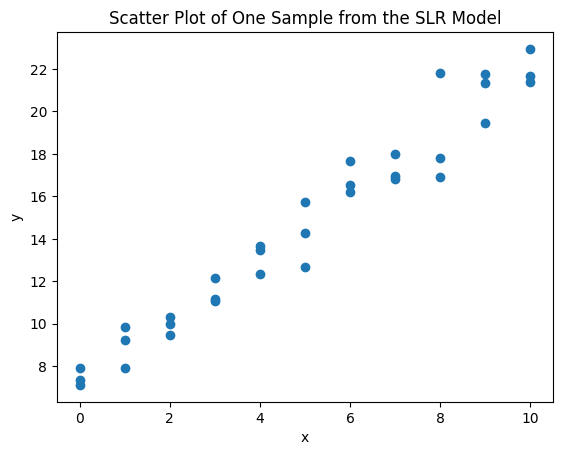

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression

# Set up the random number generator and true parameters
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# Create x values: three copies of integers 0–10 (n=33)
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)
n = 33

# Generate one sample of responses from the true model
y = beta_0 + beta_1 * x + rng.standard_normal(n)

# Visualize the initial dataset
plt.scatter(x=x, y=y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot of One Sample from the SLR Model")
plt.show()

### Simulation: 5000 Slope Estimates

Now I'm going to run 5000 simulations. Here's what I do in each iteration:
1. Generate new $y$ values from the true model (with fresh random noise each time)
2. Use `sklearn` to fit a linear regression and grab the slope estimate $\hat{\beta}_1$
3. Save that slope estimate

The $x$ values stay the same the whole time—only the error term changes between simulations.

In [ ]:
# Use a fresh rng with a fixed seed for reproducibility
rng_sim = default_rng(42)

# Reshape x for sklearn (needs 2D array)
x_reshaped = x.reshape(-1, 1)

# Storage for slope estimates
num_simulations = 5000
slope_estimates = np.empty(num_simulations)

# Run the simulation
for i in range(num_simulations):
    # Step 1: Generate y from the true model with new random noise
    y_sim = beta_0 + beta_1 * x + rng_sim.standard_normal(n)

    # Step 2: Fit linear regression using sklearn
    model = LinearRegression()
    model.fit(x_reshaped, y_sim)

    # Step 3: Save the estimated slope
    slope_estimates[i] = model.coef_[0]

print(f"Simulation complete: {num_simulations} slope estimates stored.")
print(f"Mean of simulated slopes: {np.mean(slope_estimates):.4f}  (true beta_1 = {beta_1})")
print(f"Std Dev of simulated slopes: {np.std(slope_estimates):.4f}")

Simulation complete: 5000 slope estimates stored.
Mean of simulated slopes: 1.4999  (true beta_1 = 1.5)
Std Dev of simulated slopes: 0.0549


### Histogram of the Sampling Distribution

Now let me plot all 5000 slope estimates as a histogram. This shows me the **sampling distribution of the slope** — basically, how much the slope estimate bounces around from sample to sample.

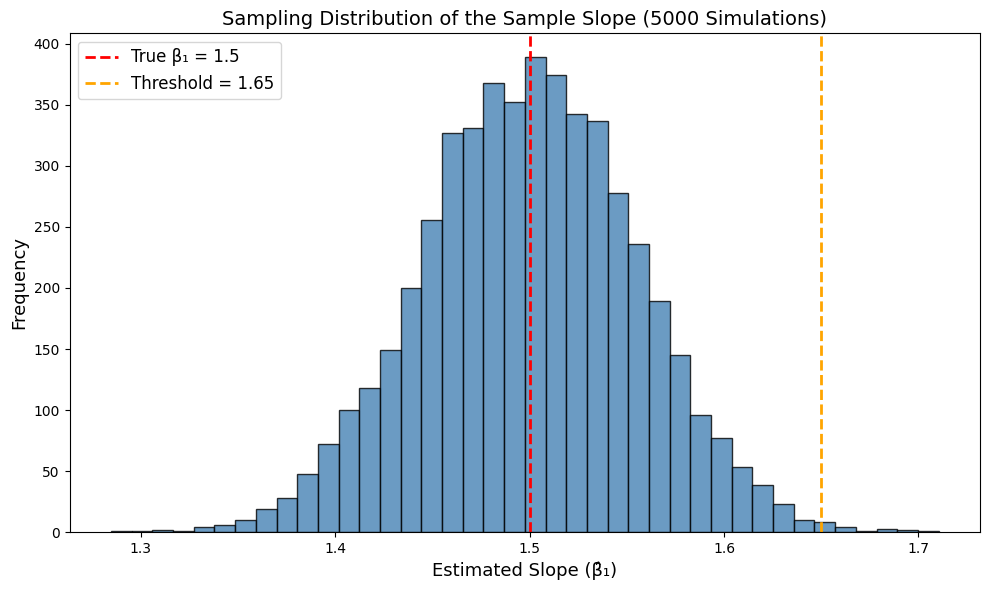

In [ ]:
# Plot the sampling distribution of the sample slope
plt.figure(figsize=(10, 6))
plt.hist(slope_estimates, bins=40, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(x=beta_1, color='red', linewidth=2, linestyle='--', label=f'True β₁ = {beta_1}')
plt.axvline(x=1.65, color='orange', linewidth=2, linestyle='--', label='Threshold = 1.65')
plt.xlabel("Estimated Slope (β̂₁)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title("Sampling Distribution of the Sample Slope (5000 Simulations)", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Probability of Sample Slope > 1.65

For this part, I just count: out of 5000 simulated slopes, how many were bigger than 1.65? That gives me an estimate of the probability.

In [ ]:
# Approximate P(slope > 1.65) using the simulated sampling distribution
threshold = 1.65
prob_above_threshold = np.mean(slope_estimates > threshold)

print(f"Approximate P(β̂₁ > {threshold}) = {prob_above_threshold:.4f}")
print(f"This means about {prob_above_threshold*100:.2f}% of simulated slopes exceed {threshold}.")

Approximate P(β̂₁ > 1.65) = 0.0028
This means about 0.28% of simulated slopes exceed 1.65.


### Interpretation & Connection to Hypothesis Testing

So what does this probability actually tell me? It's basically the chance of seeing a slope as big as 1.65 **if the true slope really is 1.5**.

**How this connects to hypothesis testing:**

Say I want to test whether the true slope is actually 1.5 or if it's bigger:

$H_0: \beta_1 = 1.5 \quad$ vs. $\quad H_a: \beta_1 > 1.5$

If I actually observed a slope of 1.65, I'd ask myself: *"How weird would it be to get 1.65 (or something bigger) if the true slope really is 1.5?"* That's exactly what my simulated probability tells me—it's the **p-value** for my test.

- If the p-value is tiny (like 0.05 or less), that's pretty weird—I should reject the null hypothesis and say the slope is probably different from 1.5.
- If the p-value is high, observing 1.65 isn't that unusual under the null, so I keep the null hypothesis.

The cool thing about simulation is that I can get p-values without needing fancy theoretical formulas. As long as I can simulate the data, I can figure out what's likely and what's not.

---
## Part III – Big Data Examples & Rare Events

### Question 5 – Bias in Machine Learning Models

#### Example: Facial Recognition Systems

**Why it's biased:**
Facial recognition algorithms are notorious for messing up on women and people with darker skin, but working great on white guys. What's going on? The problem is almost always in the training data. Datasets scraped from the internet or conference photos tend to have way more light-skinned male faces. Like, one major dataset was over 77% men and 83% light-skinned people. When a model trains mostly on one demographic group, it gets really good at that group and kinda gives up on others.

**How to fix it:**
There are several ways to tackle this:
1. **Collect better training data:** Deliberately make sure you're getting a diverse mix of people in your dataset.
2. **Generate synthetic data:** Use GANs or other techniques to create more examples of underrepresented groups.
3. **Weight the training:** Make the model care more about getting the underrepresented groups right by increasing the penalty when it misclassifies them.
4. **Test fairly:** Don't just look at overall accuracy. Break down performance by demographic group and make sure it's good for everyone.
5. **Get diverse teams:** Have people from different backgrounds building the model. They'll catch biases that might slip past a homogeneous team.

### Question 6 – Big Data in the Earth Sciences

#### Focus Area: Climate and Weather Modeling

**What's happening:**
Climate and weather scientists are drowning in data these days—satellites everywhere, weather stations scattered around, ocean buoys, atmosphere sensors... They combine all this with reanalysis datasets like ERA5 (which is 83 years of hourly global atmospheric data, by the way) to understand climate and predict weather. They're using machine learning—neural networks, random forests, the works—to figure out patterns like how El Niño throws the whole global climate out of whack, or to predict where hurricanes and floods are going to hit. It's a ton of data.

**But here's the catch—lots of biases:**
- **Geographically uneven:** Most weather stations are in North America, Europe, or East Asia. Africa? The oceans? The poles? Not so much. When your model is trained on biased data like that, it's going to stink at predicting weather in data-sparse areas.
- **Old data is sparse:** Before satellites existed (before 1979), we just didn't have as many observations. If I'm trying to look at climate trends over a century, mixing those sparse old records with new dense data is asking for trouble.
- **Sensors change:** Instruments have changed over time, measurement methods have shifted, stations have moved... All that creates weird errors that are hard to even spot.
- **Ships weren't random:** We used to measure ocean temperatures mainly from wherever ships went (which was basically trade routes). So some parts of the ocean are way oversampled while others are ignored.

This stuff matters because climate scientists are using these models to make predictions that influence policy. Garbage in, garbage out.

### Question 7 – Rare Events

**Let's talk about bridge failure**

Bridges failing is extremely rare, but when they do, it's a disaster. Engineers put sensors all over bridges (stress, vibration, temperature, etc.) and collect tons of data to figure out when a structure might be about to fail. They need to estimate the probability of failure under different conditions like heavy rain, earthquakes, or rush hour traffic.

Here's the problem: if you naively train a model on historical data, basically everything in the data is "no failure." The model sees like 99.9% examples of bridges that didn't fall and gets confused about what actually matters. So you can't just use generic machine learning—you've gotta use special techniques like extreme value theory or oversampling the rare failure cases (similar to what fraud detection does) to teach the model to care about the warning signals. That way you can actually plan for low-probability, high-impact events.

---
## Part IV – Querying a Database

Now I'm going to connect to the Lahman baseball database (it's in SQLite) and run some queries to pull out specific info. I'll use `pandas.read_sql()` to convert the results into DataFrames.

In [ ]:
# Import libraries for database work
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/lahman_1871-2022.sqlite')

### Question 8 – List All Tables in the Database

Let me see what tables are actually in this database. I'll query the `sqlite_master` table, which is a special table that SQLite keeps to track its own structure.

In [ ]:
# Query all table names from the SQLite schema
query_tables = """
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

tables_df = pd.read_sql(query_tables, conn)
print(f"The Lahman database contains {len(tables_df)} tables:")
tables_df

The Lahman database contains 27 tables:


,table_name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


### Question 9 – All Teams That Played in 2015

I want to get every team that played in 2015 with all their stats. So I'll grab all rows from the `Teams` table where the year was 2015.

In [ ]:
# Return all teams that played in 2015 with all columns
query_teams_2015 = """
SELECT *
FROM Teams
WHERE yearID = 2015;
"""

teams_2015 = pd.read_sql(query_teams_2015, conn)
print(f"Number of teams in 2015: {len(teams_2015)}")
teams_2015.head()

Number of teams in 2015: 30


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET


### Question 10 – Players Inducted into the Hall of Fame

Time to find the Hall of Famers. I'll look in the `HallOfFame` table and get only the ones where `inducted = 'Y'`, along with when they got in and what category.

In [ ]:
# Return all Hall of Fame inductees: playerID, year inducted, and category
query_hof = """
SELECT playerID, yearID, category
FROM HallOfFame
WHERE inducted = 'Y'
ORDER BY yearID, playerID;
"""

hof_df = pd.read_sql(query_hof, conn)
print(f"Number of Hall of Fame inductees: {len(hof_df)}")
hof_df.head(10)

Number of Hall of Fame inductees: 340


,playerID,yearid,category
0,cobbty01,1936,Player
1,johnswa01,1936,Player
2,mathech01,1936,Player
3,ruthba01,1936,Player
4,wagneho01,1936,Player
5,bulkemo99,1937,Pioneer/Executive
6,johnsba99,1937,Pioneer/Executive
7,lajoina01,1937,Player
8,mackco01,1937,Manager
9,mcgrajo01,1937,Manager


### Question 11 – All Unique Managers of the Pittsburgh Pirates

The Pirates have had a bunch of managers over the years. I'll use `SELECT DISTINCT` to pull out each unique manager ID from the `Managers` table where the team is 'PIT'. The DISTINCT part makes sure I don't get duplicate names if someone managed for multiple seasons.

In [ ]:
# Return unique managers of the Pittsburgh Pirates
query_pit_managers = """
SELECT DISTINCT playerID
FROM Managers
WHERE teamID = 'PIT'
ORDER BY playerID;
"""

pit_managers = pd.read_sql(query_pit_managers, conn)
print(f"Number of unique Pittsburgh Pirates managers: {len(pit_managers)}")
pit_managers

Number of unique Pittsburgh Pirates managers: 41


,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


### Question 12 – Managers Inducted into the Hall of Fame

Now I want to find managers who also made it to the Hall of Fame. I need to join the `HallOfFame` and `Managers` tables to find people who did both—that is, they managed a team AND got inducted. I'll use an inner join to find the overlap.

In [ ]:
# Return unique playerIDs for managers who were inducted into the Hall of Fame
query_hof_managers = """
SELECT DISTINCT m.playerID
FROM Managers m
INNER JOIN HallOfFame h
    ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
ORDER BY m.playerID;
"""

hof_managers = pd.read_sql(query_hof_managers, conn)

# Programmatically report the count using pandas
num_hof_managers = len(hof_managers)
print(f"Number of managers inducted into the Hall of Fame: {num_hof_managers}")
hof_managers

Number of managers inducted into the Hall of Fame: 97


,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


### Question 13 – Win/Loss Records for Hall of Fame Managers

I want to see the career win/loss records for all the managers in the Hall of Fame. So I'll pull every season each of them managed, add up all their wins and losses, calculate their win percentage, and rank them from best to worst. I'll use SQL to do the join, then pandas to aggregate and sort.

In [ ]:
# Step 1: Use SQL JOIN to get every season managed by each HOF manager
# Return playerID, G (games), W (wins), L (losses) from the Managers table
query_hof_seasons = """
SELECT m.playerID, m.G, m.W, m.L
FROM Managers m
INNER JOIN HallOfFame h
    ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
ORDER BY m.playerID;
"""

hof_seasons = pd.read_sql(query_hof_seasons, conn)
print(f"Total season-rows for HOF managers: {len(hof_seasons)}")
hof_seasons.head(10)

Total season-rows for HOF managers: 996


,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
5,alstowa01,156,88,68
6,alstowa01,154,82,72
7,alstowa01,154,89,65
8,alstowa01,165,102,63
9,alstowa01,163,99,63


In [ ]:
# Step 2 & 3: Aggregate wins/losses per manager, then compute win percentage
hof_records = (
    hof_seasons
    .groupby('playerID', as_index=False)
    .agg(Total_W=('W', 'sum'), Total_L=('L', 'sum'))
)

# Create win/loss percentage variable: W / (W + L)
hof_records['Win_Pct'] = hof_records['Total_W'] / (hof_records['Total_W'] + hof_records['Total_L'])

# Step 4: Sort by win percentage from largest to smallest
hof_records = hof_records.sort_values('Win_Pct', ascending=False).reset_index(drop=True)

print("Hall of Fame Managers – Career Win/Loss Records (sorted by Win %):")
hof_records.round(4)

Hall of Fame Managers – Career Win/Loss Records (sorted by Win %):


,playerID,Total_W,Total_L,Win_Pct
0,simmote01,1,0,1.0000
1,wrighge01,59,25,0.7024
2,spaldal01,78,47,0.6240
3,mccarjo99,2125,1333,0.6145
4,comisch01,840,541,0.6083
...,...,...,...,...
92,bottoji01,21,56,0.2727
93,applilu01,10,30,0.2500
94,baineha01,1,3,0.2500
95,wagneho01,1,4,0.2000


In [ ]:
# Close the database connection when done
conn.close()
print("Database connection closed.")

Database connection closed.
